# TinyGPT From Scratch

## Phase 1: Environment Setup

### Goal

Prepare the development environment and establish a baseline configuration for the first TinyGPT model.

### Baseline Model (Version 1.0)

- Tokenizer: Character-Level
- Context Length: 128
- Embedding Dimension: 128
- Attention Heads: 4
- Transformer Layers: 2
- Feed Forward Dimension: 512
- Dropout: 0.1
- Optimizer: Adam
- Learning Rate: 3e-4

### Hardware Constraint

This project is designed for a laptop with approximately 2GB of dedicated GPU memory.

We will build one working model first and then perform controlled experiments by changing one parameter at a time.


## Import Libraries

In [1]:
!pip install torch torchvision torchaudio

In [5]:
!pip install pandas

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.8 MB 1.9 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.8 MB 2.3 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.8 MB 2.5 MB/s eta 0:00:04
   ---------- ----------------------------- 2.6/9.8 MB 2.6 MB/s eta 0:00:03
   ------------ --------------------------- 3.1/9.8 MB 2.6 MB/s eta 0:00:03
   --------------- ------------------------ 3.9/9.8 MB 2.6 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.8 MB 2.8 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.8 MB 2.9 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.8 MB 3.0 MB/s eta 0:00:02
   ---------------------------- --------

In [7]:
!pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 1.4 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.3 MB 2.4 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.3 MB 2.9 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/9.3 MB 3.0 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.3 MB 2.9 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.3 MB 3.0 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 3.0 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.3 MB 3.1 MB/s eta 0:00:02
   ---------------------------- ----------- 6.6/9.3 MB 3.2 MB/s eta 0:00:01
   ------------------------------ --------- 7.1/9.3 MB 3.2 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.3 MB 3.2 MB/s eta 0:00:01
   -----------------------

In [9]:
!pip install tqdm

In [14]:
!pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------- ----------------- 524.3/914.9 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 2.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.2 MB 4.8 MB/s eta 0:00:01
   ----------------------- ---------------- 1.3/2.2 MB 3.0 MB/s eta 0:00:01
   ---------------------------- ----------- 1.6/2.2 MB 3.0 MB/s eta 0:00:01
   --------------------------------- ------ 1.8/2.2 MB 2.3 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 2.3 MB/s  0:00:00

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
  

In [1]:
import math
import random
import platform
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print("Libraries imported successfully.")

Libraries imported successfully.


## Set Random Seed

In [3]:
# =========================================================
# Reproducibility
# =========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    print(f"Random seed set to {SEED}")

Random seed set to 42


## Base Line Configuration

In [4]:
# =========================================================
# Baseline TinyGPT Configuration (Version 1.0)
# =========================================================

CONFIG = {
    # Dataset / tokenizer
    "tokenizer": "character",

    # Model
    "context_length": 128,
    "embedding_dim": 128,
    "num_heads": 4,
    "num_layers": 2,
    "feedforward_dim": 512,
    "dropout": 0.1,

    # Training
    "batch_size": 16,
    "epochs": 10,
    "learning_rate": 3e-4,
    "optimizer": "Adam",
}

CONFIG

{'tokenizer': 'character',
 'context_length': 128,
 'embedding_dim': 128,
 'num_heads': 4,
 'num_layers': 2,
 'feedforward_dim': 512,
 'dropout': 0.1,
 'batch_size': 16,
 'epochs': 10,
 'learning_rate': 0.0003,
 'optimizer': 'Adam'}

## Select Device

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [ ]:
!pip install --no-cache-dir torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [5]:
# =========================================================
# Device Selection
# =========================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


## System Information

In [6]:
# =========================================================
# System Information
# =========================================================

print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)

print(f"Operating System : {platform.system()} {platform.release()}")
print(f"Python Version   : {platform.python_version()}")
print(f"PyTorch Version  : {torch.__version__}")
print(f"Selected Device  : {DEVICE}")

SYSTEM INFORMATION
Operating System : Windows 11
Python Version   : 3.12.13
PyTorch Version  : 2.5.1+cu121
Selected Device  : cuda


In [7]:
import sys, torch, subprocess

print("1. Python Path:", sys.executable)
print("2. PyTorch Version:", torch.__version__)
print("3. CUDA Available:", torch.cuda.is_available())

try:
    smi = subprocess.check_output("nvidia-smi", shell=True).decode("utf-8")
    print("\n4. NVIDIA Driver Status:\n", "\n".join(smi.split("\n")[:10]))
except Exception as e:
    print("\n4. NVIDIA Driver Status: Failed to run nvidia-smi command.")


1. Python Path: C:\Users\DELL\anaconda3\envs\gpu_env\python.exe
2. PyTorch Version: 2.5.1+cu121
3. CUDA Available: True

4. NVIDIA Driver Status:
 Thu Jul 30 12:18:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.47                 KMD Version: 610.47        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce MX570 A       WDDM  |   00000000:02:00.0 Off |                  N/A |
| N/A   51C    P0              8W /   30W |       0MiB /   2048MiB |      0%      Def

## GPU Information

In [8]:
# =========================================================
# GPU Information
# =========================================================

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    total_memory_gb = (
        torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    )

    print(f"GPU Name   : {gpu_name}")
    print(f"GPU Memory : {total_memory_gb:.2f} GB")
else:
    print("CUDA is not available. Training will run on CPU.")

GPU Name   : NVIDIA GeForce MX570 A
GPU Memory : 2.00 GB


## Tiny Tensor Test

In [9]:
# =========================================================
# PyTorch Device Test
# =========================================================

x = torch.randn(3, 3).to(DEVICE)
y = torch.randn(3, 3).to(DEVICE)

z = x @ y

print("Tensor X:")
print(x)

print("\nTensor Y:")
print(y)

print("\nX @ Y:")
print(z)

print(f"\nOutput device: {z.device}")

Tensor X:
tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617]], device='cuda:0')

Tensor Y:
tensor([[ 0.2674,  0.5349,  0.8094],
        [ 1.1103, -1.6898, -0.9890],
        [ 0.9580,  1.3221,  0.8172]], device='cuda:0')

X @ Y:
tensor([[ 0.4576,  0.2724,  0.3367],
        [-1.3636,  1.7743,  1.1446],
        [ 0.3243,  2.8696,  2.7954]], device='cuda:0')

Output device: cuda:0


## VRAM Sanity Check

In [10]:
# =========================================================
# Current GPU Memory Usage
# =========================================================

if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / (1024 ** 2)
    reserved = torch.cuda.memory_reserved() / (1024 ** 2)

    print(f"Allocated VRAM : {allocated:.2f} MB")
    print(f"Reserved VRAM  : {reserved:.2f} MB")
else:
    print("No GPU memory to report.")

Allocated VRAM : 8.13 MB
Reserved VRAM  : 22.00 MB


## Phase 1 Verification

In [11]:
# =========================================================
# Phase 1 Verification
# =========================================================

print("=" * 60)
print("PHASE 1 COMPLETED")
print("=" * 60)

for key, value in CONFIG.items():
    print(f"{key:18}: {value}")

print("-" * 60)
print(f"Device: {DEVICE}")
print("Environment is ready for Phase 2 (Dataset Preparation).")

PHASE 1 COMPLETED
tokenizer         : character
context_length    : 128
embedding_dim     : 128
num_heads         : 4
num_layers        : 2
feedforward_dim   : 512
dropout           : 0.1
batch_size        : 16
epochs            : 10
learning_rate     : 0.0003
optimizer         : Adam
------------------------------------------------------------
Device: cuda
Environment is ready for Phase 2 (Dataset Preparation).


# Phase Two - Data Preparation

## Objective

In this phase, we will prepare the text corpus that will be used to train TinyGPT.

The tasks include:

- Downloading a publicly available dataset
- Loading the dataset into memory
- Exploring the dataset
- Cleaning and normalizing the text
- Preparing the cleaned corpus for tokenization

At the end of this phase, we will have a clean text corpus ready for building our tokenizer.

## Import Additional Libraries

In [30]:
!pip install scikit-learn seaborn scipy transformers evaluate accelerate diffusers requests openpyxl ipywidgets tqdm datasets

  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.18.0-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached transformers-5.14.1-py3-none-any.whl.metadata (32 kB)
  Using cached evaluate-0.4.6-py3-none-any.whl.metadata (9.5 kB)
  Using cached accelerate-1.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached diffusers-0.39.0-py3-none-any.whl.metadata (20 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached datasets-5.0.1-py3-none-any.whl.metadata (23 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached huggingface_hub-1.25.1-py3-none-any.whl.metadata (16 kB)
  Using cached regex-2026.7.19-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-w

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\DELL\\anaconda3\\envs\\gpu_env\\Lib\\site-packages\\diffusers\\pipelines\\deprecated\\i2vgen_xl\\pipeline_i2vgen_xl.py'
Consider using the `--user` option or check the permissions.



In [12]:
# ==========================================================
# Phase 2 - Import Additional Libraries
# ==========================================================

import re
from collections import Counter
import datasets
from datasets import load_dataset

print("Additional libraries imported successfully.")

Additional libraries imported successfully.


## Download Tiny Stories Dataset

In [13]:
# ==========================================================
# Phase 2 - Download Dataset
# ==========================================================

print("Downloading TinyStories...")

dataset = load_dataset(
    "roneneldan/TinyStories",
    split="train"
)

print("Download completed.")

Download completed.


## Inspect The Dataset

In [14]:
# ==========================================================
# Phase 2 - Dataset Overview
# ==========================================================

print(dataset)

print("\nNumber of stories:", len(dataset))

print("\nDataset features:")

print(dataset.features)

Dataset({
    features: ['text'],
    num_rows: 2119719
})

Number of stories: 2119719

Dataset features:
{'text': Value('string')}


## Display Sample Stories

In [15]:
# ==========================================================
# Phase 2 - Display Sample Stories
# ==========================================================

NUM_SAMPLES = 3

for i in range(NUM_SAMPLES):

    print("="*80)
    print(f"Story {i+1}")
    print("="*80)

    print(dataset[i]["text"][:1000])

    print("\n")

Story 1
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


Story 2
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves th

## Compute Basic Dataset Statistics

In [16]:
# ==========================================================
# Phase 2 - Dataset Statistics
# ==========================================================

story_lengths = []

total_characters = 0

total_words = 0

for story in dataset:

    text = story["text"]

    chars = len(text)

    words = len(text.split())

    story_lengths.append(words)

    total_characters += chars

    total_words += words

print("="*60)

print("DATASET STATISTICS")

print("="*60)

print(f"Total Stories      : {len(dataset):,}")

print(f"Total Words        : {total_words:,}")

print(f"Total Characters   : {total_characters:,}")

print(f"Average Story Size : {np.mean(story_lengths):.2f} words")

print(f"Shortest Story     : {min(story_lengths)} words")

print(f"Longest Story      : {max(story_lengths)} words")

DATASET STATISTICS
Total Stories      : 2,119,719
Total Words        : 371,713,604
Total Characters   : 1,899,973,203
Average Story Size : 175.36 words
Shortest Story     : 0 words
Longest Story      : 963 words


## Visualize Story Length Distribution

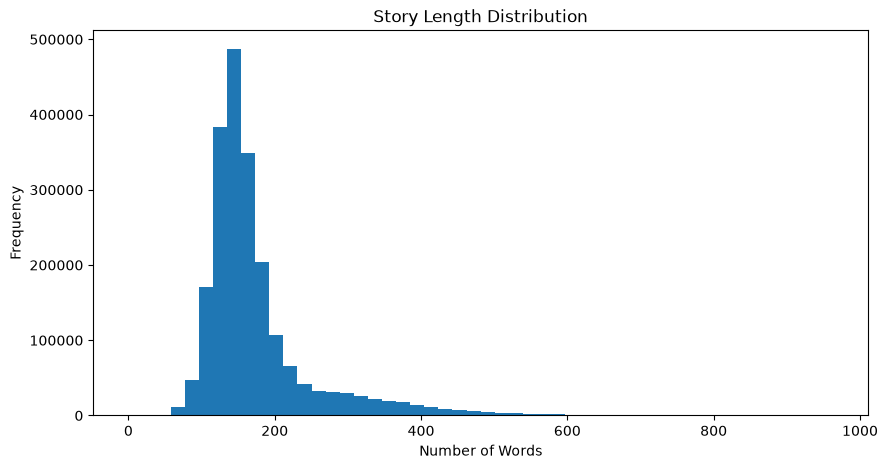

In [17]:
# ==========================================================
# Phase 2 - Story Length Distribution
# ==========================================================

plt.figure(figsize=(10,5))

plt.hist(story_lengths, bins=50)

plt.title("Story Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

## Data Cleaning Function

In [18]:
# ==========================================================
# Phase 2 - Text Cleaning
# ==========================================================

def clean_text(text):

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text

## Clean The Dataset

In [19]:
# ==========================================================
# Phase 2 - Clean Dataset
# ==========================================================

clean_corpus = []

for story in dataset:

    cleaned = clean_text(story["text"])

    clean_corpus.append(cleaned)

print("Total cleaned stories:", len(clean_corpus))

Total cleaned stories: 2119719


## Compare Original to Cleaned

In [20]:
# ==========================================================
# Phase 2 - Before and After Cleaning
# ==========================================================

index = 0

print("="*60)

print("ORIGINAL")

print("="*60)

print(dataset[index]["text"][:700])

print("\n")

print("="*60)

print("CLEANED")

print("="*60)

print(clean_corpus[index][:700])

ORIGINAL
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together


CLEANED
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt. Lily went to her mom and said, "Mom, I found this needle. Can you sh

## Corpus Statistics after Cleaning

In [21]:
# ==========================================================
# Phase 2 - Clean Corpus Statistics
# ==========================================================

character_counter = Counter()

word_counter = Counter()

for story in clean_corpus:

    character_counter.update(story)

    word_counter.update(story.split())

print("="*60)

print("Unique Characters :", len(character_counter))

print("Unique Words      :", len(word_counter))

Unique Characters : 171
Unique Words      : 265840


## Most Common Characters

In [22]:
# ==========================================================
# Phase 2 - Character Frequency
# ==========================================================

print(character_counter.most_common(30))

[(' ', 369594115), ('e', 180782399), ('a', 127963378), ('t', 118625067), ('o', 99438049), ('h', 93158669), ('n', 88723326), ('i', 81541616), ('d', 81365133), ('s', 78717020), ('r', 69065494), ('l', 58624581), ('y', 43340874), ('m', 37596074), ('w', 37345470), ('.', 36459483), ('u', 36000193), ('g', 27778517), ('c', 27360663), ('p', 26533250), ('f', 21490736), ('b', 20514498), ('k', 18233556), (',', 17359980), ('T', 12367802), ('v', 10977240), ('"', 10017440), ('S', 7399489), ('H', 5631352), ("'", 4338335)]


## Most Common Words

In [23]:
# ==========================================================
# Phase 2 - Word Frequency
# ==========================================================

print(word_counter.most_common(30))

[('and', 17805228), ('the', 16600203), ('to', 12595921), ('a', 11358820), ('was', 9339022), ('She', 4615120), ('He', 4467640), ('They', 4362812), ('her', 4128963), ('it', 3678390), ('The', 3602311), ('he', 3475829), ('she', 3079339), ('in', 3077134), ('with', 3004958), ('his', 2839591), ('of', 2627084), ('that', 2477298), ('had', 2379263), ('they', 2377811), ('so', 2327468), ('Lily', 2194666), ('for', 1971360), ('very', 1879152), ('on', 1864725), ('little', 1794254), ('said,', 1766673), ('you', 1735126), ('is', 1636522), ('there', 1628142)]


## Phase Two Verification

In [24]:
CONFIG = {

    # Dataset
    "dataset_name": "TinyStories",

    # Tokenizer
    "tokenizer": "character",

    # Model
    "context_length": 128,
    "embedding_dim": 128,
    "num_heads": 4,
    "num_layers": 2,
    "feedforward_dim": 512,
    "dropout": 0.1,

    # Training
    "batch_size": 16,
    "epochs": 10,
    "learning_rate": 3e-4,
    "optimizer": "Adam",
}

In [25]:
# ==========================================================
# Phase 2 Verification
# ==========================================================

print("="*60)

print("PHASE 2 COMPLETED")

print("="*60)

print(f"Dataset Name          : {CONFIG['dataset_name']}")

print(f"Stories Loaded        : {len(clean_corpus):,}")

print(f"Unique Characters     : {len(character_counter)}")

print(f"Unique Words          : {len(word_counter):,}")

print(f"Average Story Length  : {np.mean(story_lengths):.2f} words")

print("="*60)

print("Dataset Ready for Tokenization ✓")

PHASE 2 COMPLETED
Dataset Name          : TinyStories
Stories Loaded        : 2,119,719
Unique Characters     : 171
Unique Words          : 265,840
Average Story Length  : 175.36 words
Dataset Ready for Tokenization ✓


# Phase 3 — Character Tokenization

## Objective

In this phase, we will build our own character-level tokenizer without relying on external libraries.

The tokenizer will:

- Build a vocabulary from the cleaned corpus
- Assign a unique integer ID to every character
- Convert text into numerical IDs (encoding)
- Convert IDs back into text (decoding)
- Verify that the tokenizer performs a lossless round-trip conversion

The resulting tokenizer will be used to prepare data for TinyGPT Version 1.0.

## Build Character Vocabulary

In [26]:
# ==========================================================
# Phase 3.1 - Build Character Vocabulary
# ==========================================================

print("Building character vocabulary...")

# Collect all unique characters from the cleaned corpus
unique_characters = sorted(set("".join(clean_corpus)))

# Reserve index 0 for padding
PAD_TOKEN = "<PAD>"

vocabulary = [PAD_TOKEN] + unique_characters

print(f"Vocabulary Size: {len(vocabulary)}")
print(f"First 20 Tokens:\n{vocabulary[:20]}")

Building character vocabulary...
Vocabulary Size: 172
First 20 Tokens:
['<PAD>', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2']


## Create lookup Tables

In [27]:
# ==========================================================
# Phase 3.2 - Create Lookup Tables
# ==========================================================

char_to_index = {
    character: index
    for index, character in enumerate(vocabulary)
}

index_to_char = {
    index: character
    for character, index in char_to_index.items()
}

print(f"Total Vocabulary: {len(char_to_index)}")

print("\nSample Mapping")

for character in list(char_to_index.keys())[:15]:
    print(f"{repr(character):>8} --> {char_to_index[character]}")

Total Vocabulary: 172

Sample Mapping
 '<PAD>' --> 0
     ' ' --> 1
     '!' --> 2
     '"' --> 3
     '#' --> 4
     '$' --> 5
     '%' --> 6
     '&' --> 7
     "'" --> 8
     '(' --> 9
     ')' --> 10
     '*' --> 11
     '+' --> 12
     ',' --> 13
     '-' --> 14


## Character Encoding

In [28]:
# ==========================================================
# Phase 3.3 - Character Encoding
# ==========================================================

def encode(text):
    """
    Convert text into a list of integer IDs.
    """

    return [
        char_to_index[character]
        for character in text
    ]

## Character Decoding

In [29]:
# ==========================================================
# Phase 3.4 - Character Decoding
# ==========================================================

def decode(token_ids):
    """
    Convert integer IDs back into text.
    """

    return "".join(
        index_to_char[token]
        for token in token_ids
        if token != 0
    )

## Test Encoding

In [30]:
# ==========================================================
# Phase 3.5 - Encoding Example
# ==========================================================

sample_text = clean_corpus[0][:200]

encoded = encode(sample_text)

print(sample_text)

print("\nEncoded Representation:\n")

print(encoded[:100])

print(f"\nTotal Tokens: {len(encoded)}")

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on

Encoded Representation:

[48, 78, 69, 1, 68, 65, 89, 13, 1, 65, 1, 76, 73, 84, 84, 76, 69, 1, 71, 73, 82, 76, 1, 78, 65, 77, 69, 68, 1, 45, 73, 76, 89, 1, 70, 79, 85, 78, 68, 1, 65, 1, 78, 69, 69, 68, 76, 69, 1, 73, 78, 1, 72, 69, 82, 1, 82, 79, 79, 77, 15, 1, 52, 72, 69, 1, 75, 78, 69, 87, 1, 73, 84, 1, 87, 65, 83, 1, 68, 73, 70, 70, 73, 67, 85, 76, 84, 1, 84, 79, 1, 80, 76, 65, 89, 1, 87, 73, 84, 72]

Total Tokens: 200


## Test Decoding

In [31]:
# ==========================================================
# Phase 3.6 - Decoding Example
# ==========================================================

decoded = decode(encoded)

print(decoded)

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on


## Round-Trip Verification

In [32]:
# ==========================================================
# Phase 3.7 - Round-Trip Verification
# ==========================================================

test_sentence = clean_corpus[5][:300]

encoded = encode(test_sentence)

decoded = decode(encoded)

print("Original == Decoded ?")

print(test_sentence == decoded)

Original == Decoded ?
True


## Vocabulary Statistics

In [33]:
# ==========================================================
# Phase 3.8 - Vocabulary Statistics
# ==========================================================

print("=" * 60)
print("CHARACTER VOCABULARY")
print("=" * 60)

print(f"Vocabulary Size : {len(vocabulary)}")

print(f"Padding Index   : {char_to_index[PAD_TOKEN]}")

print("\nCharacters")

print(vocabulary)

CHARACTER VOCABULARY
Vocabulary Size : 172
Padding Index   : 0

Characters
['<PAD>', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~', '¡', '¢', '£', '¤', '¥', '¦', '§', '¨', '©', 'ª', '«', '¬', '\xad', '®', '¯', '°', '±', '²', '³', '´', 'µ', '¶', '·', '¸', '¹', 'º', '»', '¼', '½', '¾', '¿', 'Â', 'Ã', 'Ä', 'Å', 'É', 'Ê', 'Ñ', 'Ò', 'á', 'â', 'ã', 'ä', 'å', 'æ', 'ç', 'è', 'é', 'î', 'ï', 'ð', 'Œ', 'œ', 'Š', 'š', 'Ÿ', 'Ž', 'ž', 'ƒ', 'ˆ', '˜', '–', '‘', '’', '‚', '“', '”', '„', '†', '‡', '•', '…', '‰', '‹', '›', '€', '™']


## Character Frequency

In [34]:
# ==========================================================
# Phase 3.9 - Character Frequency
# ==========================================================

character_counts = {}

for story in clean_corpus:
    for character in story:
        character_counts[character] = (
            character_counts.get(character, 0) + 1
        )

sorted_counts = sorted(
    character_counts.items(),
    key=lambda item: item[1],
    reverse=True
)

print("Top 30 Most Frequent Characters\n")

for character, count in sorted_counts[:30]:
    print(f"{repr(character):>6} : {count:,}")

Top 30 Most Frequent Characters

   ' ' : 369,594,115
   'e' : 180,782,399
   'a' : 127,963,378
   't' : 118,625,067
   'o' : 99,438,049
   'h' : 93,158,669
   'n' : 88,723,326
   'i' : 81,541,616
   'd' : 81,365,133
   's' : 78,717,020
   'r' : 69,065,494
   'l' : 58,624,581
   'y' : 43,340,874
   'm' : 37,596,074
   'w' : 37,345,470
   '.' : 36,459,483
   'u' : 36,000,193
   'g' : 27,778,517
   'c' : 27,360,663
   'p' : 26,533,250
   'f' : 21,490,736
   'b' : 20,514,498
   'k' : 18,233,556
   ',' : 17,359,980
   'T' : 12,367,802
   'v' : 10,977,240
   '"' : 10,017,440
   'S' : 7,399,489
   'H' : 5,631,352
   "'" : 4,338,335


## Visualize Character Frequency

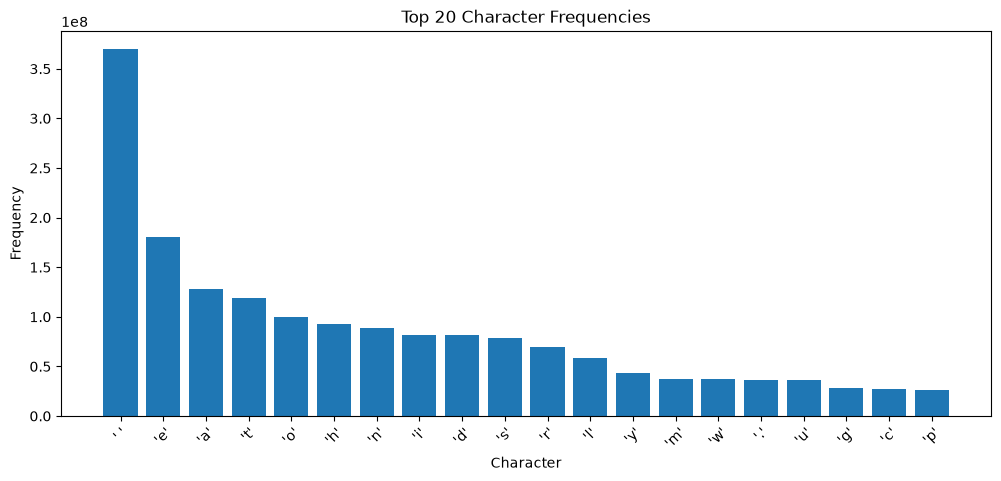

In [35]:
# ==========================================================
# Phase 3.10 - Character Frequency Plot
# ==========================================================

top_characters = sorted_counts[:20]

labels = [repr(item[0]) for item in top_characters]

counts = [item[1] for item in top_characters]

plt.figure(figsize=(12,5))

plt.bar(labels, counts)

plt.title("Top 20 Character Frequencies")

plt.xlabel("Character")

plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

## Phase Three Verification

In [36]:
# ==========================================================
# Phase 3 Verification
# ==========================================================

print("=" * 60)

print("PHASE 3 COMPLETED")

print("=" * 60)

print(f"Tokenizer Type        : {CONFIG['tokenizer']}")

print(f"Vocabulary Size       : {len(vocabulary)}")

print(f"Padding Token Index   : {char_to_index[PAD_TOKEN]}")

print(f"Sample Encoding Length: {len(encoded)}")

print("=" * 60)

print("Character Tokenizer Ready ✓")

PHASE 3 COMPLETED
Tokenizer Type        : character
Vocabulary Size       : 172
Padding Token Index   : 0
Sample Encoding Length: 300
Character Tokenizer Ready ✓


# Phase 4 — Efficient Dataset Pipeline

## Objective

In this phase we prepare the tokenized corpus for training.

Unlike the previous implementation that generated and stored every possible context window in memory, this implementation creates training samples only when they are requested by the DataLoader.

This greatly reduces RAM usage and makes the pipeline scalable to much larger datasets.

## Encode Entire Corpus

In [37]:
# ==========================================================
# Phase 4.1 - Encode Entire Corpus
# ==========================================================

print("Encoding corpus...")

encoded_corpus = []

for story in clean_corpus:
    encoded_corpus.extend(encode(story))

print(f"Total Tokens : {len(encoded_corpus):,}")

print("\nFirst 50 Tokens")

print(encoded_corpus[:50])

Encoding corpus...
Total Tokens : 1,889,019,292

First 50 Tokens
[48, 78, 69, 1, 68, 65, 89, 13, 1, 65, 1, 76, 73, 84, 84, 76, 69, 1, 71, 73, 82, 76, 1, 78, 65, 77, 69, 68, 1, 45, 73, 76, 89, 1, 70, 79, 85, 78, 68, 1, 65, 1, 78, 69, 69, 68, 76, 69, 1, 73]


## Convert to Pytorch Tensors

In [38]:
# ==========================================================
# Phase 4.2 - Convert Corpus to Tensor
# ==========================================================

all_tokens = torch.tensor(
    encoded_corpus,
    dtype=torch.long
)

print(type(all_tokens))

print(all_tokens.shape)

<class 'torch.Tensor'>
torch.Size([1889019292])


## Train/Validation Split

In [39]:
# ==========================================================
# Phase 4.3 - Train Validation Split
# ==========================================================

split = int(len(all_tokens) * 0.9)

train_tokens = all_tokens[:split]

valid_tokens = all_tokens[split:]

print("Training Tokens :", len(train_tokens))

print("Validation Tokens:", len(valid_tokens))

Training Tokens : 1700117362
Validation Tokens: 188901930


## Random Window Dataset

In [44]:
# ==========================================================
# Phase 4.4 - Random Window Dataset
# ==========================================================

from torch.utils.data import Dataset


class GPTDataset(Dataset):

    def __init__(self, tokens, context_length):

        self.tokens = tokens
        self.context_length = context_length

    def __len__(self):
        # Number of possible starting positions
        return len(self.tokens) - self.context_length - 1

    def __getitem__(self, index):
        # Ignore the incoming index.
        # Instead, choose a random starting position.
        start = torch.randint(
            0,
            len(self.tokens) - self.context_length - 1,
            (1,)
        ).item()

        x = self.tokens[
            start:start+self.context_length
        ]

        y = self.tokens[
            start+1:start+self.context_length+1
        ]

        return x, y

## Dataset Objects

In [45]:
# ==========================================================
# Phase 4.5 - Dataset Objects
# ==========================================================

train_dataset = GPTDataset(
    train_tokens,
    CONFIG["context_length"]
)

valid_dataset = GPTDataset(
    valid_tokens,
    CONFIG["context_length"]
)

print(f"Training Samples : {len(train_dataset):,}")
print(f"Validation Samples : {len(valid_dataset):,}")

Training Samples : 1,700,117,233
Validation Samples : 188,901,801


## Data Loaders

In [46]:
# ==========================================================
# Phase 4.6 - DataLoaders
# ==========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    drop_last=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    drop_last=True
)

print("DataLoaders Ready.")

DataLoaders Ready.


## Inspect Batch

In [47]:
# ==========================================================
# Phase 4.7 - Inspect Batch
# ==========================================================

x, y = next(iter(train_loader))

print("Input Shape :", x.shape)
print("Target Shape:", y.shape)

Input Shape : torch.Size([16, 128])
Target Shape: torch.Size([16, 128])


## Decode Example

In [48]:
# ==========================================================
# Phase 4.8 - Decode Example
# ==========================================================

example = 0

print("=" * 60)
print("INPUT")
print("=" * 60)

print(decode(x[example].tolist()))

print()

print("=" * 60)
print("TARGET")
print("=" * 60)

print(decode(y[example].tolist()))

INPUT
Ben looks at Mia. He sees her eyes. He feels bad. He knows Mia is right. He feels guilty for taking the rock. "Okay, Mia, you ar

TARGET
en looks at Mia. He sees her eyes. He feels bad. He knows Mia is right. He feels guilty for taking the rock. "Okay, Mia, you are


## Phase Four Verification

In [49]:
# ==========================================================
# Phase 4 Verification
# ==========================================================

print("=" * 60)

print("PHASE 4 COMPLETED")

print("=" * 60)

print(f"Total Tokens      : {len(all_tokens):,}")
print(f"Training Tokens   : {len(train_tokens):,}")
print(f"Validation Tokens : {len(valid_tokens):,}")
print(f"Vocabulary Size   : {len(vocabulary):,}")
print(f"Context Length    : {CONFIG['context_length']}")
print(f"Batch Size        : {CONFIG['batch_size']}")

print("=" * 60)

print("Efficient Dataset Pipeline Ready ✓")

PHASE 4 COMPLETED
Total Tokens      : 1,889,019,292
Training Tokens   : 1,700,117,362
Validation Tokens : 188,901,930
Vocabulary Size   : 172
Context Length    : 128
Batch Size        : 16
Efficient Dataset Pipeline Ready ✓


# Phase 5 — TinyGPT Architecture

## Objective

In this phase we implement the TinyGPT model from scratch using PyTorch.

Each module is implemented and tested independently before integrating them into the final model.

Components:

- Token Embedding
- Positional Embedding
- Self-Attention
- Multi-Head Attention
- Feed Forward Network
- Transformer Block
- TinyGPT

## Import Pytorch Modules

In [50]:
# ==========================================================
# Phase 5.1 - Import Neural Network Modules
# ==========================================================

import torch.nn as nn
import torch.nn.functional as F

print("PyTorch neural network modules imported successfully.")

PyTorch neural network modules imported successfully.


## Model Hyperparameters

In [51]:
# ==========================================================
# Phase 5.2 - Model Hyperparameters
# ==========================================================

VOCAB_SIZE = len(vocabulary)

CONTEXT_LENGTH = CONFIG["context_length"]

EMBED_DIM = CONFIG["embedding_dim"]

NUM_HEADS = CONFIG["num_heads"]

NUM_LAYERS = CONFIG["num_layers"]

FF_DIM = CONFIG["feedforward_dim"]

DROPOUT = CONFIG["dropout"]

print(f"Vocabulary Size : {VOCAB_SIZE}")
print(f"Embedding Dim   : {EMBED_DIM}")
print(f"Attention Heads : {NUM_HEADS}")
print(f"Transformer Layers : {NUM_LAYERS}")

Vocabulary Size : 172
Embedding Dim   : 128
Attention Heads : 4
Transformer Layers : 2


## Token Embeddings

In [52]:
# ==========================================================
# Phase 5.3 - Token Embedding
# ==========================================================

token_embedding = nn.Embedding(
    num_embeddings=VOCAB_SIZE,
    embedding_dim=EMBED_DIM
)

print(token_embedding)

Embedding(172, 128)


## Test Token Embeddings

In [53]:
# ==========================================================
# Phase 5.4 - Verify Token Embedding
# ==========================================================

sample_batch = next(iter(train_loader))[0]

embedded = token_embedding(sample_batch)

print("Input Shape :", sample_batch.shape)

print("Embedding Shape :", embedded.shape)

Input Shape : torch.Size([16, 128])
Embedding Shape : torch.Size([16, 128, 128])


## Positional Embeddings

In [54]:
# ==========================================================
# Phase 5.5 - Positional Embedding
# ==========================================================

position_embedding = nn.Embedding(

    num_embeddings=CONTEXT_LENGTH,

    embedding_dim=EMBED_DIM

)

print(position_embedding)

Embedding(128, 128)


## Test Positional Embeddings

In [55]:
# ==========================================================
# Phase 5.6 - Verify Position Embedding
# ==========================================================

positions = torch.arange(

    CONTEXT_LENGTH

).unsqueeze(0)

positions = positions.expand(

    sample_batch.size(0),

    CONTEXT_LENGTH

)

position_vectors = position_embedding(

    positions

)

print(position_vectors.shape)

torch.Size([16, 128, 128])


## Combine Embeddings

In [56]:
# ==========================================================
# Phase 5.7 - Combine Token + Position Embeddings
# ==========================================================

x = embedded + position_vectors

print(x.shape)

torch.Size([16, 128, 128])


## Inspect One Token

In [57]:
# ==========================================================
# Phase 5.8 - Inspect Embedding Vector
# ==========================================================

print(x[0,0])

tensor([-0.6154,  0.7927,  0.7301,  3.1374,  0.6901, -0.3095, -0.2200,  0.7080,
        -1.5792, -1.0496,  1.0617,  2.9762, -0.3534, -1.0793,  3.2924, -0.2702,
         0.4341, -1.5615, -1.8036,  1.1263,  0.8905,  1.1965, -0.0842, -1.1510,
        -3.7526,  0.1557, -1.7500, -0.6362, -0.4845, -2.8027, -0.8795,  0.5193,
        -0.7021,  0.7244,  0.0762, -0.5579,  0.2005, -2.1382,  0.6171, -0.4430,
         0.1215, -0.4308,  0.5119, -0.6164,  0.1952, -0.2961,  0.1445,  1.8218,
        -0.0096, -1.2501, -0.1542, -0.8484,  0.3439, -0.2319, -0.2684, -0.6797,
        -1.8627, -0.3025,  0.2477,  1.0035, -2.4014,  1.6918,  0.4972,  1.8494,
        -0.9594, -1.6654, -1.1701, -3.6201,  0.9326, -0.2237, -1.8359,  1.0023,
        -1.5358, -1.0320,  3.4601, -1.7402, -0.0669, -1.6415,  1.2031,  2.2881,
         1.5892,  1.5303,  0.8557,  2.1698, -0.8199, -2.7308,  1.5078,  1.9660,
        -1.2135, -1.0460,  1.0922,  2.0052,  0.6014,  1.1186,  3.0997,  0.3944,
         0.1341,  0.9776,  0.4394,  1.26

## Parameter Count

In [58]:
# ==========================================================
# Phase 5.9 - Embedding Parameters
# ==========================================================

token_params = sum(
    p.numel()
    for p in token_embedding.parameters()
)

position_params = sum(
    p.numel()
    for p in position_embedding.parameters()
)

print("="*60)

print("Embedding Parameters")

print("="*60)

print(f"Token Embedding     : {token_params:,}")

print(f"Position Embedding  : {position_params:,}")

print(f"Total               : {token_params+position_params:,}")

Embedding Parameters
Token Embedding     : 22,016
Position Embedding  : 16,384
Total               : 38,400


## Phase Five Verification

In [59]:
# ==========================================================
# Phase 5 Verification
# ==========================================================

print("="*60)

print("PHASE 5A COMPLETED")

print("="*60)

print(f"Vocabulary Size : {VOCAB_SIZE}")

print(f"Embedding Size  : {EMBED_DIM}")

print(f"Context Length  : {CONTEXT_LENGTH}")

print("="*60)

print("Embedding Layer Ready ✓")

PHASE 5A COMPLETED
Vocabulary Size : 172
Embedding Size  : 128
Context Length  : 128
Embedding Layer Ready ✓


# Phase 5B — Scaled Dot-Product Self-Attention

## Objective

Implement a single causal self-attention head from scratch.

The attention head learns relationships between tokens by computing Query, Key and Value vectors and applying scaled dot-product attention with a causal mask.

This module will later be combined into Multi-Head Attention.

## Single Attention Head

In [60]:
# ==========================================================
# Phase 5B.1 - Single Attention Head
# ==========================================================

class SelfAttentionHead(nn.Module):
    """
    Single causal self-attention head.
    """

    def __init__(self, embed_dim, head_dim, context_length, dropout):

        super().__init__()

        self.query = nn.Linear(embed_dim, head_dim, bias=False)
        self.key = nn.Linear(embed_dim, head_dim, bias=False)
        self.value = nn.Linear(embed_dim, head_dim, bias=False)

        self.dropout = nn.Dropout(dropout)

        # Causal mask
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(context_length, context_length))
        )

    def forward(self, x):

        B, T, C = x.shape

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        scores = Q @ K.transpose(-2, -1)

        scores = scores / (K.size(-1) ** 0.5)

        scores = scores.masked_fill(
            self.mask[:T, :T] == 0,
            float("-inf")
        )

        attention = F.softmax(scores, dim=-1)

        attention = self.dropout(attention)

        output = attention @ V

        return output

## Create One Attention Head

In [61]:
# ==========================================================
# Phase 5B.2 - Instantiate Attention Head
# ==========================================================

HEAD_DIM = EMBED_DIM // NUM_HEADS

attention_head = SelfAttentionHead(
    embed_dim=EMBED_DIM,
    head_dim=HEAD_DIM,
    context_length=CONTEXT_LENGTH,
    dropout=DROPOUT
)

print(attention_head)

SelfAttentionHead(
  (query): Linear(in_features=128, out_features=32, bias=False)
  (key): Linear(in_features=128, out_features=32, bias=False)
  (value): Linear(in_features=128, out_features=32, bias=False)
  (dropout): Dropout(p=0.1, inplace=False)
)


## Forward Pass

In [62]:
# ==========================================================
# Phase 5B.3 - Forward Pass
# ==========================================================

attention_output = attention_head(x)

print("Input Shape :", x.shape)

print("Output Shape:", attention_output.shape)

Input Shape : torch.Size([16, 128, 128])
Output Shape: torch.Size([16, 128, 32])


## Verify Casual Mask

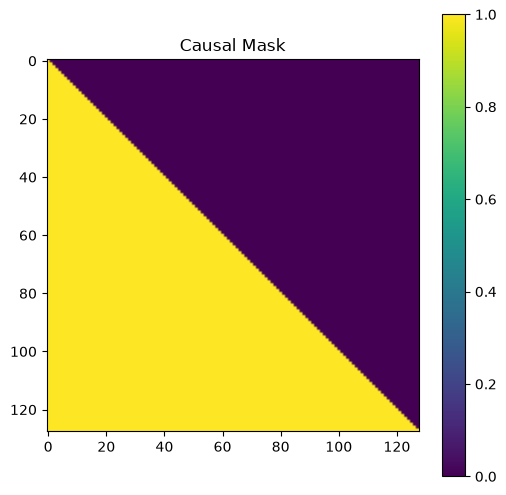

In [63]:
# ==========================================================
# Phase 5B.4 - Verify Mask
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(attention_head.mask.cpu())

plt.title("Causal Mask")

plt.colorbar()

plt.show()

## Parameter Count

In [64]:
# ==========================================================
# Phase 5B.5 - Parameter Count
# ==========================================================

params = sum(

    p.numel()

    for p in attention_head.parameters()

)

print(f"Attention Head Parameters : {params:,}")

Attention Head Parameters : 12,288


# Phase 5C — Multi-Head Attention

## Objective

Combine multiple independent self-attention heads into a Multi-Head Attention module.

The outputs of all heads are concatenated and projected back to the embedding dimension.

## Multi_Head Attention

In [65]:
# ==========================================================
# Phase 5C.1 - Multi-Head Attention
# ==========================================================

class MultiHeadAttention(nn.Module):
    """
    Multi-head causal self-attention.
    """

    def __init__(
        self,
        embed_dim,
        num_heads,
        context_length,
        dropout
    ):

        super().__init__()

        head_dim = embed_dim // num_heads

        self.heads = nn.ModuleList(

            [

                SelfAttentionHead(

                    embed_dim,

                    head_dim,

                    context_length,

                    dropout

                )

                for _ in range(num_heads)

            ]

        )

        self.projection = nn.Linear(

            embed_dim,

            embed_dim

        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        out = torch.cat(

            [

                head(x)

                for head in self.heads

            ],

            dim=-1

        )

        out = self.projection(out)

        out = self.dropout(out)

        return out

## Instantiate Module

In [66]:
# ==========================================================
# Phase 5C.2 - Create Multi-Head Attention
# ==========================================================

multi_head_attention = MultiHeadAttention(

    embed_dim=EMBED_DIM,

    num_heads=NUM_HEADS,

    context_length=CONTEXT_LENGTH,

    dropout=DROPOUT

)

print(multi_head_attention)

MultiHeadAttention(
  (heads): ModuleList(
    (0-3): 4 x SelfAttentionHead(
      (query): Linear(in_features=128, out_features=32, bias=False)
      (key): Linear(in_features=128, out_features=32, bias=False)
      (value): Linear(in_features=128, out_features=32, bias=False)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (projection): Linear(in_features=128, out_features=128, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


## Foward pass

In [67]:
# ==========================================================
# Phase 5C.3 - Forward Pass
# ==========================================================

multi_output = multi_head_attention(x)

print("Input Shape :", x.shape)

print("Output Shape:", multi_output.shape)

Input Shape : torch.Size([16, 128, 128])
Output Shape: torch.Size([16, 128, 128])


## Parameter Count

In [68]:
# ==========================================================
# Phase 5C.4 - Parameter Count
# ==========================================================

params = sum(

    p.numel()

    for p in multi_head_attention.parameters()

)

print(f"Multi-Head Parameters : {params:,}")

Multi-Head Parameters : 65,664


## Verify Output Statistics

In [69]:
# ==========================================================
# Phase 5C.5 - Output Statistics
# ==========================================================

print("="*60)

print("Output Mean :", multi_output.mean().item())

print("Output Std  :", multi_output.std().item())

print("Output Min  :", multi_output.min().item())

print("Output Max  :", multi_output.max().item())

Output Mean : 3.5067962016910315e-05
Output Std  : 0.15664361417293549
Output Min  : -1.6723865270614624
Output Max  : 2.0058789253234863


# Phase 5D — Feed-Forward Network

## Objective

Implement the position-wise feed-forward network used after the attention mechanism.

Each token is processed independently through a small neural network:

Linear → GELU → Linear → Dropout

## Feedfoward Network

In [70]:
# ==========================================================
# Phase 5D.1 - Feed Forward Network
# ==========================================================

class FeedForward(nn.Module):
    """
    Position-wise Feed Forward Network.
    """

    def __init__(self, embed_dim, hidden_dim, dropout):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(embed_dim, hidden_dim),

            nn.GELU(),

            nn.Linear(hidden_dim, embed_dim),

            nn.Dropout(dropout)

        )

    def forward(self, x):

        return self.network(x)

## Instantiat Feedfoward

In [71]:
# ==========================================================
# Phase 5D.2 - Create Feed Forward
# ==========================================================

feed_forward = FeedForward(

    embed_dim=EMBED_DIM,

    hidden_dim=FF_DIM,

    dropout=DROPOUT

)

print(feed_forward)

FeedForward(
  (network): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): Dropout(p=0.1, inplace=False)
  )
)


## Foward Pass

In [72]:
# ==========================================================
# Phase 5D.3 - Forward Pass
# ==========================================================

ff_output = feed_forward(x)

print("Input Shape :", x.shape)

print("Output Shape:", ff_output.shape)

Input Shape : torch.Size([16, 128, 128])
Output Shape: torch.Size([16, 128, 128])


## Parameter Count

In [73]:
# ==========================================================
# Phase 5D.4 - Parameter Count
# ==========================================================

params = sum(

    p.numel()

    for p in feed_forward.parameters()

)

print(f"Feed Forward Parameters : {params:,}")

Feed Forward Parameters : 131,712


# Phase 5E — Transformer Block

## Objective

Combine:

- Layer Normalization
- Multi-Head Attention
- Feed Forward Network
- Residual Connections

to build one Transformer block.

## Transformer Block

In [74]:
# ==========================================================
# Phase 5E.1 - Transformer Block
# ==========================================================

class TransformerBlock(nn.Module):
    """
    Pre-LayerNorm Transformer Block.
    """

    def __init__(
        self,
        embed_dim,
        num_heads,
        context_length,
        hidden_dim,
        dropout
    ):

        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attention = MultiHeadAttention(

            embed_dim,

            num_heads,

            context_length,

            dropout

        )

        self.norm2 = nn.LayerNorm(embed_dim)

        self.feed_forward = FeedForward(

            embed_dim,

            hidden_dim,

            dropout

        )

    def forward(self, x):

        x = x + self.attention(

            self.norm1(x)

        )

        x = x + self.feed_forward(

            self.norm2(x)

        )

        return x

## Instantiate Block

In [75]:
# ==========================================================
# Phase 5E.2 - Create Transformer Block
# ==========================================================

transformer_block = TransformerBlock(

    embed_dim=EMBED_DIM,

    num_heads=NUM_HEADS,

    context_length=CONTEXT_LENGTH,

    hidden_dim=FF_DIM,

    dropout=DROPOUT

)

print(transformer_block)

TransformerBlock(
  (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (attention): MultiHeadAttention(
    (heads): ModuleList(
      (0-3): 4 x SelfAttentionHead(
        (query): Linear(in_features=128, out_features=32, bias=False)
        (key): Linear(in_features=128, out_features=32, bias=False)
        (value): Linear(in_features=128, out_features=32, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (projection): Linear(in_features=128, out_features=128, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (feed_forward): FeedForward(
    (network): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=512, out_features=128, bias=True)
      (3): Dropout(p=0.1, inplace=False)
    )
  )
)


## Forward pass

In [76]:
# ==========================================================
# Phase 5E.3 - Forward Pass
# ==========================================================

block_output = transformer_block(x)

print("Input Shape :", x.shape)

print("Output Shape:", block_output.shape)

Input Shape : torch.Size([16, 128, 128])
Output Shape: torch.Size([16, 128, 128])


## Parameter Count

In [77]:
# ==========================================================
# Phase 5E.4 - Parameter Count
# ==========================================================

params = sum(

    p.numel()

    for p in transformer_block.parameters()

)

print(f"Transformer Block Parameters : {params:,}")

Transformer Block Parameters : 197,888


## Verify Residual Learning

In [78]:
# ==========================================================
# Phase 5E.5 - Residual Check
# ==========================================================

difference = (block_output - x).abs().mean().item()

print("=" * 60)

print("Mean Absolute Difference")

print("=" * 60)

print(difference)

Mean Absolute Difference
0.17991554737091064


## Output Statistics

In [79]:
# ==========================================================
# Phase 5E.6 - Output Statistics
# ==========================================================

print("=" * 60)

print("Mean :", block_output.mean().item())

print("Std  :", block_output.std().item())

print("Min  :", block_output.min().item())

print("Max  :", block_output.max().item())

Mean : 0.039153628051280975
Std  : 1.4170819520950317
Min  : -6.05154275894165
Max  : 6.430943965911865


## Phase Verification

In [80]:
# ==========================================================
# Phase 5 Verification
# ==========================================================

print("=" * 60)

print("PHASE 5D & 5E COMPLETED")

print("=" * 60)

print(f"Embedding Dimension : {EMBED_DIM}")

print(f"Attention Heads     : {NUM_HEADS}")

print(f"Feed Forward Dim    : {FF_DIM}")

print(f"Transformer Layers  : {NUM_LAYERS}")

print("=" * 60)

print("Transformer Block Ready ✓")

PHASE 5D & 5E COMPLETED
Embedding Dimension : 128
Attention Heads     : 4
Feed Forward Dim    : 512
Transformer Layers  : 2
Transformer Block Ready ✓


# Phase 5F — TinyGPT Model

## Objective

Assemble the complete TinyGPT model from the modules implemented in the previous phases.

Components:

- Token Embedding
- Position Embedding
- Transformer Blocks
- Final Layer Normalization
- Language Modeling Head
- Weight Tying

The output of the model is a tensor of logits over the vocabulary for every position in the input sequence.

## TinyGPT Model

In [81]:
# ==========================================================
# Phase 5F.1 - TinyGPT Model
# ==========================================================

class TinyGPT(nn.Module):
    """
    TinyGPT Language Model
    """

    def __init__(
        self,
        vocab_size,
        context_length,
        embed_dim,
        num_heads,
        num_layers,
        hidden_dim,
        dropout
    ):

        super().__init__()

        # Token embedding
        self.token_embedding = nn.Embedding(
            vocab_size,
            embed_dim
        )

        # Position embedding
        self.position_embedding = nn.Embedding(
            context_length,
            embed_dim
        )

        # Transformer stack
        self.blocks = nn.Sequential(

            *[
                TransformerBlock(
                    embed_dim,
                    num_heads,
                    context_length,
                    hidden_dim,
                    dropout
                )

                for _ in range(num_layers)
            ]

        )

        # Final LayerNorm
        self.final_norm = nn.LayerNorm(embed_dim)

        # Language Model Head
        self.lm_head = nn.Linear(
            embed_dim,
            vocab_size,
            bias=False
        )

        # Weight tying
        self.lm_head.weight = self.token_embedding.weight

    def forward(self, x):

        B, T = x.shape

        positions = torch.arange(
            T,
            device=x.device
        )

        positions = positions.unsqueeze(0).expand(B, T)

        token_embeddings = self.token_embedding(x)

        position_embeddings = self.position_embedding(
            positions
        )

        x = token_embeddings + position_embeddings

        x = self.blocks(x)

        x = self.final_norm(x)

        logits = self.lm_head(x)

        return logits

## Instantiate TinyGPT

In [82]:
# ==========================================================
# Phase 5F.2 - Instantiate Model
# ==========================================================

model = TinyGPT(

    vocab_size=VOCAB_SIZE,

    context_length=CONTEXT_LENGTH,

    embed_dim=EMBED_DIM,

    num_heads=NUM_HEADS,

    num_layers=NUM_LAYERS,

    hidden_dim=FF_DIM,

    dropout=DROPOUT

)

print(model)

TinyGPT(
  (token_embedding): Embedding(172, 128)
  (position_embedding): Embedding(128, 128)
  (blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attention): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x SelfAttentionHead(
            (query): Linear(in_features=128, out_features=32, bias=False)
            (key): Linear(in_features=128, out_features=32, bias=False)
            (value): Linear(in_features=128, out_features=32, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (projection): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (feed_forward): FeedForward(
        (network): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
        

## Count Parameters

In [83]:
# ==========================================================
# Phase 5F.3 - Count Parameters
# ==========================================================

total_parameters = sum(

    p.numel()

    for p in model.parameters()

)

trainable_parameters = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

print("="*60)

print("MODEL PARAMETERS")

print("="*60)

print(f"Total Parameters     : {total_parameters:,}")

print(f"Trainable Parameters : {trainable_parameters:,}")

MODEL PARAMETERS
Total Parameters     : 434,432
Trainable Parameters : 434,432


## Forward Pass

In [84]:
# ==========================================================
# Phase 5F.4 - Forward Pass
# ==========================================================

sample_batch = next(iter(train_loader))[0]

logits = model(sample_batch)

print("Input Shape")

print(sample_batch.shape)

print()

print("Output Shape")

print(logits.shape)

Input Shape
torch.Size([16, 128])

Output Shape
torch.Size([16, 128, 172])


## Verify Output

In [85]:
# ==========================================================
# Phase 5F.5 - Verify Logits
# ==========================================================

print("="*60)

print("Vocabulary Size")

print("="*60)

print(logits.shape[-1])

print()

print("First Token Logits")

print()

print(logits[0,0])

Vocabulary Size
172

First Token Logits

tensor([-9.0332e+00, -4.1968e+00, -1.4762e+01, -3.3746e+00,  7.5105e-01,
         1.8778e+01, -4.5547e+00,  1.2913e+00, -5.2448e+00,  1.3843e+01,
        -3.7285e+00,  7.1743e-01,  2.1261e+00, -1.4300e+01, -7.4060e+00,
        -7.7589e+00,  7.5953e+00, -7.1721e+00, -1.2343e+01, -6.0065e+00,
        -1.6230e+01,  8.3720e+00, -1.3339e+01, -3.3805e+00,  1.0136e+01,
        -4.1308e+00, -1.3870e+01,  3.2442e+00, -5.0330e+00,  1.5811e+01,
         2.9383e+00, -4.9641e+00,  4.5732e+00,  1.7246e+01, -2.4211e+01,
        -7.4849e+00,  1.6631e+00, -1.1705e+00,  1.0361e+01,  1.5265e+01,
         1.4428e+01,  8.4422e+01, -9.2278e+00,  1.3970e+01, -1.4596e+01,
        -4.1118e+00,  8.4694e+00, -5.0870e+00, -2.0958e+01, -6.1518e+00,
        -1.9511e+00, -2.1698e+00,  4.4330e+00,  1.6245e+01,  3.8822e+00,
         8.2950e+00,  5.2510e+00, -2.0236e+00, -1.6406e+00,  3.7973e+00,
        -7.1276e-01, -5.5792e+00,  3.2710e+00,  8.2181e+00, -3.8598e+00,
         7

## Test prediction

In [86]:
# ==========================================================
# Phase 5F.6 - Predict Next Character
# ==========================================================

prediction = torch.argmax(

    logits,

    dim=-1

)

print("Prediction Shape")

print(prediction.shape)

print()

print("Decoded Prediction")

print(decode(prediction[0].tolist()))

Prediction Shape
torch.Size([16, 128])

Decoded Prediction
He flew down and began talking to the pig. The bird said, "Greetings! It's so nice to meet a humble pink pig like you." The pig 


## Verify Weight Tying

In [87]:
# ==========================================================
# Phase 5F.7 - Verify Weight Tying
# ==========================================================

print("="*60)

print("Weight Tying Verification")

print("="*60)

print(

    model.token_embedding.weight.data_ptr()

    ==

    model.lm_head.weight.data_ptr()

)

Weight Tying Verification
True


## Move model to Device

In [88]:
# ==========================================================
# Phase 5F.8 - Move Model to Device
# ==========================================================

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

model = model.to(device)

print("Device:", device)

Device: cuda


## Move Batch to Device

In [89]:
# ==========================================================
# Phase 5F.9 - Test GPU/CPU Forward Pass
# ==========================================================

sample_batch = sample_batch.to(device)

with torch.no_grad():

    logits = model(sample_batch)

print("Forward Pass Successful")

print()

print(logits.shape)

Forward Pass Successful

torch.Size([16, 128, 172])


In [90]:
## Phase Verification

In [91]:
# ==========================================================
# Phase 5F Verification
# ==========================================================

print("="*60)

print("PHASE 5 COMPLETED")

print("="*60)

print(f"Vocabulary Size      : {VOCAB_SIZE:,}")

print(f"Embedding Dimension  : {EMBED_DIM}")

print(f"Attention Heads      : {NUM_HEADS}")

print(f"Transformer Layers   : {NUM_LAYERS}")

print(f"Feed Forward Dim     : {FF_DIM}")

print(f"Parameters           : {total_parameters:,}")

print(f"Device               : {device}")

print("="*60)

print("TinyGPT Architecture Ready ✓")

PHASE 5 COMPLETED
Vocabulary Size      : 172
Embedding Dimension  : 128
Attention Heads      : 4
Transformer Layers   : 2
Feed Forward Dim     : 512
Parameters           : 434,432
Device               : cuda
TinyGPT Architecture Ready ✓


# Phase 6A — Model Preparation

## Objective

Prepare the TinyGPT model for training.

This phase includes:

- GPT-style weight initialization
- Device setup
- Loss function
- Optimizer
- Gradient clipping
- Model summary
- Timing utilities
- Forward pass verification
- Backward pass verification
- Optimizer verification

## Imports

In [92]:
# ==========================================================
# Phase 6A.1 - Imports
# ==========================================================

import os
import csv
import math
import time

print("Utilities imported successfully.")

Utilities imported successfully.


## GPT Weight Initialization

In [93]:
# ==========================================================
# Phase 6A.2 - GPT Weight Initialization
# ==========================================================

def initialize_weights(module):
    """
    GPT-style weight initialization.
    """

    if isinstance(module, nn.Linear):

        nn.init.normal_(module.weight, mean=0.0, std=0.02)

        if module.bias is not None:
            nn.init.zeros_(module.bias)

    elif isinstance(module, nn.Embedding):

        nn.init.normal_(module.weight, mean=0.0, std=0.02)


model.apply(initialize_weights)

print("Weights initialized.")

Weights initialized.


## Device Configuration

In [94]:
# ==========================================================
# Phase 6A.3 - Device Configuration
# ==========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Device:", device)

Device: cuda


## Loss Function

In [95]:
# ==========================================================
# Phase 6A.4 - Loss Function
# ==========================================================

criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


## Optimizer

In [96]:
# ==========================================================
# Phase 6A.5 - Optimizer
# ==========================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"]
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0
)


## Gradient Clipping

In [97]:
# ==========================================================
# Phase 6A.6 - Gradient Clipping
# ==========================================================

MAX_GRAD_NORM = 1.0

print("Gradient clipping enabled.")
print("Max Gradient Norm:", MAX_GRAD_NORM)

Gradient clipping enabled.
Max Gradient Norm: 1.0


## Model Summary

In [98]:
# ==========================================================
# Phase 6A.7 - Model Summary
# ==========================================================

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

model_size_mb = (
    total_params * 4
) / (1024 ** 2)

print("="*60)
print("TinyGPT Summary")
print("="*60)

print(f"Parameters        : {total_params:,}")
print(f"Trainable         : {trainable_params:,}")
print(f"Approx Size (MB)  : {model_size_mb:.2f}")
print(f"Embedding Dim     : {EMBED_DIM}")
print(f"Heads             : {NUM_HEADS}")
print(f"Layers            : {NUM_LAYERS}")
print(f"Optimizer         : Adam")
print(f"Learning Rate     : {CONFIG['learning_rate']}")
print(f"Device            : {device}")

TinyGPT Summary
Parameters        : 434,432
Trainable         : 434,432
Approx Size (MB)  : 1.66
Embedding Dim     : 128
Heads             : 4
Layers            : 2
Optimizer         : Adam
Learning Rate     : 0.0003
Device            : cuda


## CSV logger Setup

In [99]:
# ==========================================================
# Phase 6A.8 - Experiment Logger
# ==========================================================

LOG_FILE = "experiments.csv"

if not os.path.exists(LOG_FILE):

    with open(LOG_FILE, "w", newline="") as file:

        writer = csv.writer(file)

        writer.writerow([
            "Version",
            "Tokenizer",
            "Optimizer",
            "Embedding",
            "Heads",
            "Layers",
            "Epochs",
            "Train Loss",
            "Validation Loss",
            "Perplexity",
            "Training Time (s)",
            "Time per Epoch (s)",
            "Parameters"
        ])

print("Experiment logger ready.")

Experiment logger ready.


## Forward Pass Test

In [100]:
# ==========================================================
# Phase 6A.9 - Forward Pass Test
# ==========================================================

model.train()

inputs, targets = next(iter(train_loader))

inputs = inputs.to(device)
targets = targets.to(device)

start_time = time.perf_counter()

logits = model(inputs)

forward_time = time.perf_counter() - start_time

print("Forward pass successful.")
print(f"Forward Time: {forward_time:.4f} seconds")

Forward pass successful.
Forward Time: 0.1099 seconds


## Compute Loss

In [101]:
# ==========================================================
# Phase 6A.10 - Compute Loss
# ==========================================================

loss = criterion(
    logits.view(-1, VOCAB_SIZE),
    targets.view(-1)
)

print("Loss:", loss.item())

Loss: 5.204577445983887


## Backward Pass

In [102]:
# ==========================================================
# Phase 6A.11 - Backward Pass
# ==========================================================

optimizer.zero_grad()

loss.backward()

torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    MAX_GRAD_NORM
)

print("Backward pass completed.")

Backward pass completed.


## Gardient Verification

In [103]:
# ==========================================================
# Phase 6A.12 - Gradient Verification
# ==========================================================

total_grad_norm = 0.0

for parameter in model.parameters():

    if parameter.grad is not None:

        total_grad_norm += parameter.grad.norm().item()

print(f"Gradient Norm Sum: {total_grad_norm:.4f}")

Gradient Norm Sum: 4.2129


## Optimizer Step

In [104]:
# ==========================================================
# Phase 6A.13 - Optimizer Step
# ==========================================================

optimizer.step()

print("Optimizer step completed.")

Optimizer step completed.


## Save Initial Checkpoint

In [105]:
# ==========================================================
# Phase 6A.14 - Save Initial Checkpoint
# ==========================================================

torch.save(
    model.state_dict(),
    "tinygpt_initial.pth"
)

print("Initial checkpoint saved.")

Initial checkpoint saved.


## Phase Verification

In [106]:
# ==========================================================
# Phase 6A Verification
# ==========================================================

print("="*60)
print("PHASE 6A COMPLETED")
print("="*60)

print(f"Model Parameters : {total_params:,}")
print(f"Forward Time     : {forward_time:.4f} sec")
print(f"Initial Loss     : {loss.item():.4f}")
print(f"Checkpoint Saved : tinygpt_initial.pth")

print("="*60)
print("Model Ready for Training ✓")

PHASE 6A COMPLETED
Model Parameters : 434,432
Forward Time     : 0.1099 sec
Initial Loss     : 5.2046
Checkpoint Saved : tinygpt_initial.pth
Model Ready for Training ✓


# Phase 6B — Training Engine

## Objective

Implement a reusable training engine for TinyGPT.

Components

- train_one_epoch()
- validate_one_epoch()
- save_checkpoint()
- log_experiment()
- train_model()

This engine will be reused for every future experiment.

## Training Function

In [107]:
# ==========================================================
# Phase 6B.1 - Train One Epoch
# ==========================================================

def train_one_epoch(
    model,
    dataloader,
    optimizer,
    criterion,
    device,
    max_grad_norm
):

    model.train()

    running_loss = 0.0

    total_batches = 0

    start = time.perf_counter()

    for inputs, targets in dataloader:

        inputs = inputs.to(device)

        targets = targets.to(device)

        optimizer.zero_grad()

        logits = model(inputs)

        loss = criterion(

            logits.view(-1, VOCAB_SIZE),

            targets.view(-1)

        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_grad_norm

        )

        optimizer.step()

        running_loss += loss.item()

        total_batches += 1

    elapsed = time.perf_counter() - start

    average_loss = running_loss / total_batches

    perplexity = math.exp(average_loss)

    return average_loss, perplexity, elapsed

## Validation Function

In [108]:
# ==========================================================
# Phase 6B.2 - Validation
# ==========================================================

def validate_one_epoch(

    model,

    dataloader,

    criterion,

    device

):

    model.eval()

    running_loss = 0

    batches = 0

    with torch.no_grad():

        for inputs, targets in dataloader:

            inputs = inputs.to(device)

            targets = targets.to(device)

            logits = model(inputs)

            loss = criterion(

                logits.view(-1, VOCAB_SIZE),

                targets.view(-1)

            )

            running_loss += loss.item()

            batches += 1

    average_loss = running_loss / batches

    perplexity = math.exp(average_loss)

    return average_loss, perplexity

## Save Best Model

In [109]:
# ==========================================================
# Phase 6B.3 - Save Best Model
# ==========================================================

def save_checkpoint(

    model,

    filename

):

    torch.save(

        model.state_dict(),

        filename

    )

## Experiment Logger

In [110]:
# ==========================================================
# Phase 6B.4 - Log Experiment
# ==========================================================

def log_experiment(

    version,

    train_loss,

    val_loss,

    perplexity,

    total_time,

    epoch_time

):

    with open(LOG_FILE, "a", newline="") as file:

        writer = csv.writer(file)

        writer.writerow([

            version,

            CONFIG["tokenizer"],

            CONFIG["optimizer"],

            EMBED_DIM,

            NUM_HEADS,

            NUM_LAYERS,

            CONFIG["epochs"],

            round(train_loss,4),

            round(val_loss,4),

            round(perplexity,4),

            round(total_time,2),

            round(epoch_time,2),

            total_params

        ])

## Training Engine

In [111]:
# ==========================================================
# Phase 6B.5 - Training Engine
# ==========================================================

def train_model(

    model,

    train_loader,

    valid_loader,

    optimizer,

    criterion,

    device

):

    history = {

        "train_loss": [],

        "valid_loss": [],

        "train_ppl": [],

        "valid_ppl": []

    }

    best_loss = float("inf")

    total_start = time.perf_counter()

    for epoch in range(CONFIG["epochs"]):

        train_loss, train_ppl, epoch_time = train_one_epoch(

            model,

            train_loader,

            optimizer,

            criterion,

            device,

            MAX_GRAD_NORM

        )

        valid_loss, valid_ppl = validate_one_epoch(

            model,

            valid_loader,

            criterion,

            device

        )

        history["train_loss"].append(train_loss)

        history["valid_loss"].append(valid_loss)

        history["train_ppl"].append(train_ppl)

        history["valid_ppl"].append(valid_ppl)

        if valid_loss < best_loss:

            best_loss = valid_loss

            save_checkpoint(

                model,

                "tinygpt_best.pth"

            )

        print(

            f"Epoch {epoch+1}/{CONFIG['epochs']} | "

            f"Train Loss: {train_loss:.4f} | "

            f"Val Loss: {valid_loss:.4f} | "

            f"Train PPL: {train_ppl:.2f} | "

            f"Val PPL: {valid_ppl:.2f} | "

            f"Time: {epoch_time:.2f}s"

        )

    total_time = time.perf_counter() - total_start

    log_experiment(

        "v1.0",

        history["train_loss"][-1],

        history["valid_loss"][-1],

        history["valid_ppl"][-1],

        total_time,

        total_time / CONFIG["epochs"]

    )

    return history, total_time

## Start Training

In [ ]:
# ==========================================================
# Phase 6B.6 - Train TinyGPT
# ==========================================================

history, total_training_time = train_model(

    model,

    train_loader,

    valid_loader,

    optimizer,

    criterion,

    device

)

## Final Report

In [ ]:
# ==========================================================
# Phase 6B.7 - Training Summary
# ==========================================================

print("="*60)

print("TRAINING COMPLETE")

print("="*60)

print(f"Final Train Loss : {history['train_loss'][-1]:.4f}")

print(f"Final Val Loss   : {history['valid_loss'][-1]:.4f}")

print(f"Validation PPL   : {history['valid_ppl'][-1]:.2f}")

print(f"Training Time    : {total_training_time:.2f} sec")

print(f"Training Time    : {total_training_time/60:.2f} min")

print("="*60)

print("Best Model Saved")

print("Experiment Logged")

print("="*60)